## Importing PyTorch and other dependencies
Importing PyTorch and matplot for data visualization.

In [58]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.12.0+cu126'

## Agnostic Code Setup

In [59]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Data Preparation 

### Data loading
Data loading is done by using pandas library.

In [60]:
import pandas as pd
import torch

df = pd.read_csv(r'./Resources/assignment-data2.csv')
df.head(5) #first five data point

,x,y
0,-9.8,673.28
1,-9.6,646.12
2,-9.4,619.52
3,-9.2,593.48
4,-9.0,568.00


## Changing shape of the data for PyTorch 

Pytorch uses Tenors so we need to convert our data into the required multidimensional tensor data structure. 

In order to convert the 1 D vector consisting of scalar data points into tensors, We need to  unsqueeze the data by using the unsqueeze function from pytorch.
Here the output shape of the data shows that its been converted into a tensor of shape (50, 1);where there is 50 data points and a 1 column.

In [61]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([99, 1])
torch.Size([99, 1])


## Splitting data 
We need two data sets; one for training our model and other to test the model, so we split the dataset into two parts.

* ### Sequential Division of data:
Lets first divide the data sequencially.

In [62]:
# Split data 
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(79, 79, 20, 20)

## Visualization of training data
Lets see what the training data and testing data looks like here.

In [63]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 20});


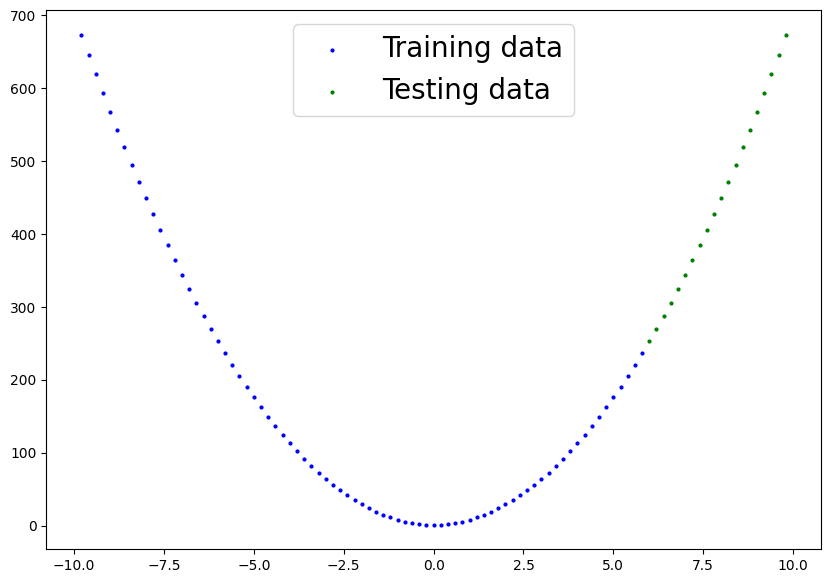

In [64]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

Here the dataset is being trained on the left wing of the quadratic curve and being tested on the right curve of the curve. This isn't going to accurately train or test our model, because our model isn't being trained on any datapoints on the right and we aren't testing the datapoints on the left. 


Therefore we need to split the dataset randomly in order to train our model using data present throughout the whole curve and also test our model using data points present throughout the whole curve.
</br>

* ### Randomly spliting data:
As we saw in the graph the sequential split of the data causes bias in training and testing data and to fix the structural bias of a sequential split, we can shuffle our dataset before dividing it. 
Shuffling mixes the rows randomly so training and testing data can represent the whole curve. By randomly selecting $80\%$ of the data points for training and saving $20\%$ for testing, we achieve two critical things:
 * Global Learning: Unlike the sequential split, our model can learn from datapoints throughout the whole curve.

 * Fair Evaluation: The model will also be teseted on the datapoints throughout the whole curve not just one side like in sequential split.

Furthermore, its important to realize that shuffling is important in building real models just like sequential splits. The way of splitting the data depends on the nature of the data itself. In this case we can see that sequential split isn't going to be the best case.

## When to sequentially split the data and when to shuffle the data?
When the order of the rows don't matter, we can shuffle the data.
When the data is time series we should split it sequentially.

In [65]:
# Set a manual seed for reproducibility so the shuffle is identical every run
torch.manual_seed(42)

# 1. Generate randomly permuted indices based on the length of our data
shuffled_indices = torch.randperm(len(X))

# 2. Shuffle both feature and label tensors using the same indices
X_shuffled = X[shuffled_indices]
y_shuffled = y[shuffled_indices]

# 3. Calculate split index (80% for training)
train_split = int(0.8 * len(X_shuffled))

# 4. Split the shuffled data into Train and Test sets
X_train, y_train = X_shuffled[:train_split], y_shuffled[:train_split]
X_test, y_test = X_shuffled[train_split:], y_shuffled[train_split:]

print(f"Shuffled Training samples: {len(X_train)} | Shuffled Testing samples: {len(X_test)}")

Shuffled Training samples: 79 | Shuffled Testing samples: 20


In [66]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 20});

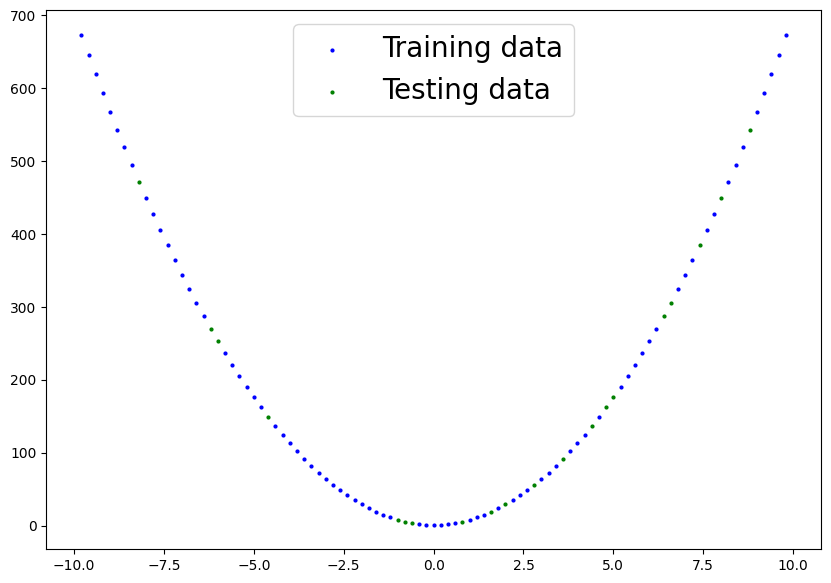

In [67]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

Here the blue dots represent the training data here and we can see that the model is being trained on the whole curve (all the way from left to right) and green dots represent the testing data and our model is being tested throughout the whole curve. Hence, shuffling the data was the correct choice to build the model for this dataset.

## Algorithm Selection
Using Quadratic Equation because the curve shows a quadratic nature.

### Model and Forward Pass

In [68]:
import torch
from torch import nn
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__() 
        self.weights_a = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                    dtype=torch.float), # <- PyTorch loves float32 by default
                                    requires_grad=True) # <- can we update this value with gradient descent?)

        self.weights_b =  nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                    dtype=torch.float), # <- PyTorch loves float32 by default
                                    requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))


    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights_a * x**2 + self.weights_b * x +self.bias # <- this is the linear regression formula (y = m*x + b)

In [69]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True),
 Parameter containing:
 tensor([0.2345], requires_grad=True)]

In [70]:
print(model_0.weights_a.dtype)
print(model_0.bias.dtype)

torch.float32
torch.float32


In [71]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[ 0.5530],
        [ 1.8388],
        [ 8.6101],
        [22.8131],
        [ 3.2348]])

In [72]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 20
Number of predictions made: 20
Predicted values:
tensor([[ 0.5530],
        [ 1.8388],
        [ 8.6101],
        [22.8131],
        [ 3.2348],
        [ 5.0617],
        [ 0.3469],
        [ 7.3195],
        [11.5825],
        [27.4413],
        [ 6.7663],
        [14.8497],
        [ 1.3025],
        [ 0.4423],
        [19.6248],
        [12.3782],
        [15.7508],
        [ 9.2958],
        [21.8173],
        [ 0.2784]])


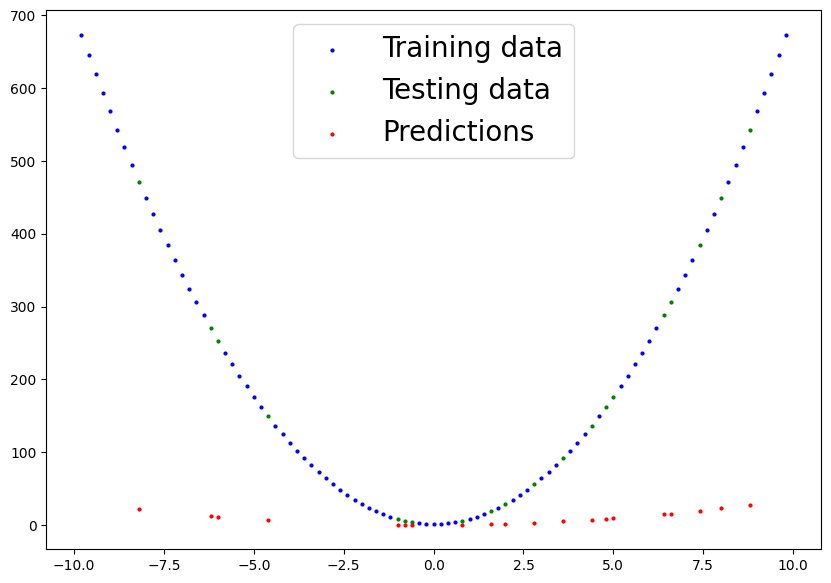

In [73]:
plot_predictions(predictions=y_preds)

## Loss Function Selection

In [74]:
# Loss Function Selection
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

In [75]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 1000

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Calculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 227.96859741210938 | MAE Test Loss: 171.5478515625 
Epoch: 10 | MAE Train Loss: 111.6424331665039 | MAE Test Loss: 79.32026672363281 
Epoch: 20 | MAE Train Loss: 4.816352367401123 | MAE Test Loss: 5.410544395446777 
Epoch: 30 | MAE Train Loss: 5.509696006774902 | MAE Test Loss: 4.879590034484863 
Epoch: 40 | MAE Train Loss: 6.1073808670043945 | MAE Test Loss: 4.418690204620361 
Epoch: 50 | MAE Train Loss: 6.5938310623168945 | MAE Test Loss: 4.022763729095459 
Epoch: 60 | MAE Train Loss: 7.080417156219482 | MAE Test Loss: 3.6439316272735596 
Epoch: 70 | MAE Train Loss: 7.423268795013428 | MAE Test Loss: 3.3762238025665283 
Epoch: 80 | MAE Train Loss: 7.716087818145752 | MAE Test Loss: 3.1370997428894043 
Epoch: 90 | MAE Train Loss: 8.008896827697754 | MAE Test Loss: 2.8979761600494385 
Epoch: 100 | MAE Train Loss: 8.30170726776123 | MAE Test Loss: 2.6588406562805176 
Epoch: 110 | MAE Train Loss: 8.526249885559082 | MAE Test Loss: 2.4850282669067383 
Epoch: 120

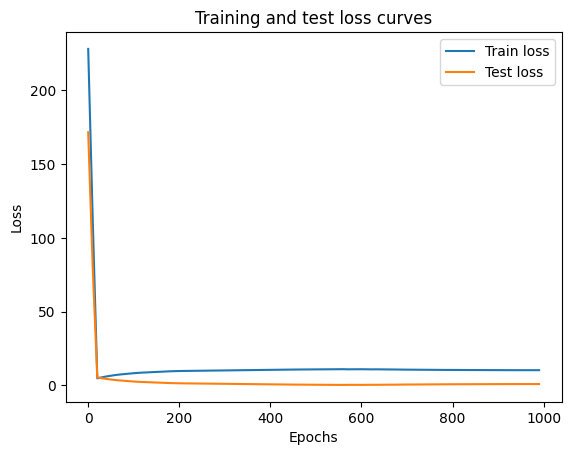

In [76]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [77]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'weights_a': tensor([7.3038]), 'weights_b': tensor([0.0343]), 'bias': tensor([1.0000])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


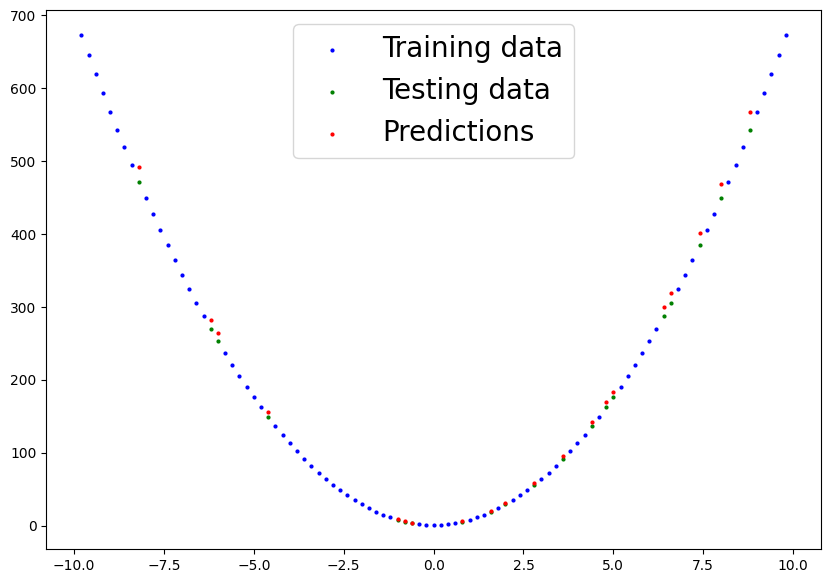

In [78]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

# Conclusion
The parabolic curve of the dataset needed to be shuffled so that we could train our entire curve and also test the model on the whole curve.

 
## The Role of Data Shuffling and Representation
 
A critical factor was shuffling the dataset before splitting it into training and testing subsets. Sequential splitting caused the model to only learn from one segment of the parabola, leaving the ascending slope entirely unseen during training. 

Shuffling the data ensured all the model was trained throughout the whole curve and also could be tested on the whole curve.
 
## Final Model Accuracy
 
Once properly shuffled and the quadratic architecture implemented, the model successfully fit the data. By explicitly passing $x^2$ as an input feature, the model gained the geometric flexibility to mimic a parabola. SGD converged steadily, producing a dramatic drop in MAE and a better prediction curve was produced.
 
